In [5]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import clickhouse_connect
import statsmodels.api as sm
from collections import namedtuple

In [6]:
class SimpleResult:
    def __init__(self, json_data):
        self.result_rows = json_data.get('data', [])
        self.column_names = [meta['name'] for meta in json_data.get('meta', [])]

class SimpleClient:
    def __init__(self, host, username, password, **kwargs):
        self.base_url = f"http://{host}:8123/"
        self.auth = {
            'user': username,
            'password': password
        }
        
    def query(self, query_string):
        params = self.auth.copy()
        # Use JSON format to get metadata (column names) easily
        params['query'] = query_string + " FORMAT JSON"
        
        response = requests.get(self.base_url, params=params)
        
        if response.status_code != 200:
            raise Exception(f"Query failed: {response.text}")
            
        return SimpleResult(response.json())

# Initialize the client
with open('../login.txt', 'r') as f:
    conn_info = eval(f.read())
    try:
        # Try to connect with clickhouse first
        client = clickhouse_connect.get_client(**conn_info)
        print("Connected using standard clickhouse_connect")
    except Exception as e:
        # If it doesn't work out, use requests
        print(f"Standard connection failed: {e}")
        print("Falling back to SimpleClient (lightweight mode)...")
        client = SimpleClient(**conn_info)
        print("Connected using SimpleClient")

Connected using standard clickhouse_connect


In [7]:
res = client.query("""show tables from fina4359_linkup_202603""")
tables = pd.DataFrame(res.result_rows, columns=res.column_names)
tables

,name
0,company_id_compustat_identifiers
1,compustat_na_quarterly_all_firms_since_2000
2,country_state_code_mapping
3,crsp_daily_ret_all_firms_since_2000
4,crsp_monthly_ret_all_firms_since_2000
...,...
378,firm_70345
379,firm_70437
380,firm_7126
381,firm_8417


In [8]:
query = """
WITH cid AS
    (SELECT 
        toInt64(REPLACE(name, 'firm_', '')) as firm_id
    FROM system.tables 
    WHERE database = 'fina4359_linkup_202603' 
    AND name LIKE 'firm_%')
SELECT company_id, toString(floor(naics / 10000)) as sector
FROM company_id_compustat_identifiers 
WHERE company_id IN (SELECT firm_id FROM cid)
"""

res = client.query(query)
firms = pd.DataFrame(res.result_rows, columns=res.column_names).dropna()
firms

,company_id,sector
0,20238,52
1,43730,32
2,44223,33
3,12903,54
4,17378,33
...,...,...
377,27814,33
378,26489,33
379,23091,52
380,24312,22


In [9]:
len(firms['sector'].unique())

24

In [10]:
def check_table_schema(company_id):
    """
    Check the actual data types and sample values
    """
    
    # Check column types
    query = f"""
    DESCRIBE TABLE firm_{company_id}
    """
    
    result = client.query(query)
    print("Table schema:")
    for row in result.result_rows:
        print(f"  {row[0]}: {row[1]}")
    
    # Check sample data
    query = f"""
    SELECT 
        created,
        last_seen,
        toTypeName(created) as created_type,
        toTypeName(last_seen) as last_seen_type
    FROM firm_{company_id}
    LIMIT 5
    """
    
    result = client.query(query)
    print("\nSample data:")
    for row in result.result_rows:
        print(f"  created: {row[0]} ({row[2]}), last_seen: {row[1]} ({row[3]})")
    
    # Check date range
    query = f"""
    SELECT 
        MIN(toDate(created)) as min_date,
        MAX(toDate(created)) as max_date,
        COUNT(*) as total_jobs
    FROM firm_{company_id}
    WHERE created IS NOT NULL
    """
    
    result = client.query(query)
    row = result.result_rows[0]
    print(f"\nDate range: {row[0]} to {row[1]}")
    print(f"Total jobs: {row[2]}")

# Run diagnostic
check_table_schema(70345)

Table schema:
  hash: Nullable(String)
  onet: Int64
  country: Int64
  state: Int64
  zip: Int64
  created: Nullable(String)
  last_updated: Nullable(String)
  updates: Int64
  last_seen: Nullable(String)
  missing: Nullable(String)
  description: Nullable(String)

Sample data:
  created: 2021-08-11 (Nullable(String)), last_seen: 2021-10-20 (Nullable(String))
  created: 2021-08-11 (Nullable(String)), last_seen: 2021-11-01 (Nullable(String))
  created: 2021-08-11 (Nullable(String)), last_seen: 2021-11-07 (Nullable(String))
  created: 2021-08-11 (Nullable(String)), last_seen: 2021-09-28 (Nullable(String))
  created: 2021-11-03 (Nullable(String)), last_seen: 2022-01-13 (Nullable(String))

Date range: 2021-08-11 to 2022-09-24
Total jobs: 15


In [11]:
def aggregate_monthly_jobs_openings(company_id, start_date='2010-01-01', end_date='2022-12-31'):
    query = f"""
    WITH 
        jobs AS (
            SELECT 
                hash,
                toDate(created) as created_date,
                toDate(last_seen) as last_seen_date
            FROM firm_{company_id}
            WHERE created IS NOT NULL 
                AND created != ''
                AND toDate(created) IS NOT NULL
        ),
        -- Generate month indices using arrayJoin
        month_indices AS (
            SELECT arrayJoin(range(0, dateDiff('month', toDate('{start_date}'), toDate('{end_date}')) + 1)) as idx
        ),
        months AS (
            SELECT 
                toDate(addMonths(toDate('{start_date}'), idx)) as month_start,
                toLastDayOfMonth(toDate(addMonths(toDate('{start_date}'), idx))) as month_end
            FROM month_indices
        )
    SELECT 
        m.month_start as month,
        COUNT(DISTINCT j.hash) as active_jobs,
        COUNT(DISTINCT CASE 
            WHEN j.created_date BETWEEN m.month_start AND m.month_end 
            THEN j.hash 
        END) as new_jobs,
        COUNT(DISTINCT CASE 
            WHEN j.last_seen_date BETWEEN m.month_start AND m.month_end 
            THEN j.hash 
        END) as closed_jobs,
        COUNT(DISTINCT CASE 
            WHEN j.created_date <= m.month_start 
                AND (j.last_seen_date IS NULL OR j.last_seen_date >= m.month_end)
            THEN j.hash 
        END) as jobs_open_full_month
    FROM months m
    CROSS JOIN jobs j
    WHERE j.created_date <= m.month_end
        AND COALESCE(j.last_seen_date, toDate('{end_date}') + 1) >= m.month_start
    GROUP BY m.month_start
    ORDER BY m.month_start
    """
    
    result = client.query(query)
    df = pd.DataFrame(
        result.result_rows, 
        columns=['month', 'active_jobs', 'new_jobs', 'closed_jobs', 'jobs_open_full_month']
    )
    return df

In [12]:
def aggregate_multiple_firms_monthly(company_ids, start_date='2010-01-01', end_date='2022-12-31'):
    """
    Aggregate monthly job openings for multiple firms simultaneously
    """
    
    # Create UNION ALL query for multiple firms
    union_queries = []
    for company_id in company_ids:
        union_queries.append(f"""
            SELECT
                {company_id} as company_id,
                hash,
                toDate(created) as created_date,
                toDate(last_seen) as last_seen_date
            FROM firm_{company_id}
            WHERE created IS NOT NULL 
                AND created != ''
                AND toDate(created) IS NOT NULL
                AND toDate(created) <= toDate('{end_date}')
        """)
    
    union_query = " UNION ALL ".join(union_queries)
    
    query = f"""
    WITH all_jobs AS (
        {union_query}
    ),
        month_indices AS (
                SELECT arrayJoin(range(0, dateDiff('month', toDate('{start_date}'), toDate('{end_date}')) + 1)) as idx
            ),
        months AS (
            SELECT 
                toDate(addMonths(toDate('{start_date}'), idx)) as month_start,
                toLastDayOfMonth(toDate(addMonths(toDate('{start_date}'), idx))) as month_end
            FROM month_indices
        )
    SELECT 
        m.month_start as month,
        COUNT(DISTINCT j.hash) as active_jobs
    FROM months m, all_jobs j
    WHERE j.created_date <= m.month_end
        AND (j.last_seen_date IS NULL OR j.last_seen_date >= m.month_start)
    GROUP BY m.month_start
    ORDER BY m.month_start
    """
    
    res = client.query(query)
    df = pd.DataFrame(res.result_rows, columns=res.column_names)
    
    return df

# Example usage
company_list = [8417, 70345, 70437]  # Replace with actual company IDs
multi_firm_df = aggregate_multiple_firms_monthly(company_list)
multi_firm_df

,month,active_jobs
0,2015-04-01,13
1,2015-05-01,23
2,2015-06-01,29
3,2015-07-01,32
4,2015-08-01,30
...,...,...
63,2022-06-01,198
64,2022-07-01,435
65,2022-08-01,258
66,2022-09-01,324


In [13]:
def get_sector_monthly_jobs(start_date='2010-01-01', end_date='2022-12-31'):
    """
    Two-step approach: first get firm-sector mapping, then aggregate
    """
    
    # Step 1: Get firm to sector mapping
    mapping_query = """
    SELECT 
        toInt64(REPLACE(t.name, 'firm_', '')) as company_id,
        toString(floor(c.naics / 10000)) as sector
    FROM system.tables t
    JOIN company_id_compustat_identifiers c
        ON toInt64(REPLACE(t.name, 'firm_', '')) = c.company_id
    WHERE t.database = 'fina4359_linkup_202603' 
        AND t.name LIKE 'firm_%'
        AND c.naics IS NOT NULL
    """
    
    mapping_result = client.query(mapping_query)
    firm_sector = {row[0]: row[1] for row in mapping_result.result_rows if row[1] != np.nan}
    
    # Step 2: Aggregate for each firm and combine
    all_data = []
    
    for company_id, sector in firm_sector.items():
        # print(f"Processing firm {company_id} (sector {sector})...")
        
        query = f"""
        WITH 
            months AS (
                SELECT 
                    toDate(addMonths(toDate('{start_date}'), idx)) as month_start,
                    toLastDayOfMonth(toDate(addMonths(toDate('{start_date}'), idx))) as month_end
                FROM (
                    SELECT arrayJoin(range(0, dateDiff('month', toDate('{start_date}'), toDate('{end_date}')) + 1)) as idx
                )
            ),
            jobs AS (
                SELECT 
                    hash,
                    toDate(created) as created_date,
                    toDate(last_seen) as last_seen_date
                FROM firm_{company_id}
                WHERE created IS NOT NULL 
                    AND created != ''
                    AND toDate(created) IS NOT NULL
            )
        SELECT 
            m.month_start as month,
            COUNT(DISTINCT j.hash) as active_jobs
        FROM months m
        CROSS JOIN jobs j
        WHERE j.created_date <= m.month_end
            AND (j.last_seen_date IS NULL OR j.last_seen_date >= m.month_start)
        GROUP BY m.month_start
        ORDER BY m.month_start
        """
        
        result = client.query(query)
        df = pd.DataFrame(result.result_rows, columns=['month', 'active_jobs'])
        df['sector'] = sector
        df['company_id'] = company_id
        all_data.append(df)
    
    # Combine all data
    final_df = pd.concat(all_data, ignore_index=True)
    
    # Aggregate by sector and month
    sector_monthly = final_df.groupby(['month', 'sector'])['active_jobs'].sum().reset_index()
    
    return sector_monthly

In [14]:
def calculate_rs_ratio(df, lookback=5):
    """
    Calculate Job Relative Strength Ratio
    df: DataFrame with columns: date, sector, active_jobs
    lookback: rolling window in months
    """
    
    # Pivot to get sectors as columns
    pivot_df = df.pivot(index='month', columns='sector', values='active_jobs').fillna(0)
    
    # Calculate monthly percentage change
    pct_change = pivot_df.pct_change()
    
    # Calculate market change (total active jobs across all sectors)
    market_change = pivot_df.sum(axis=1)
    market_pct_change = market_change.pct_change()
    
    # Calculate J-RS-Ratio for each sector
    rs_ratio = pd.DataFrame(index=pivot_df.index)
    
    for sector in pivot_df.columns:
        # RS-Ratio = (Sector % Change / Market % Change) * 100, then smoothed
        raw_ratio = (pct_change[sector] / market_pct_change) * 100
        
        # Apply J-D metric (similar to KDJ indicator) or simple moving average
        rs_ratio[sector] = raw_ratio.rolling(window=lookback, min_periods=5).mean()
        
        # Normalize to center around 100 (like Bloomberg)
        rs_ratio[sector] = 100 + (rs_ratio[sector] - rs_ratio[sector].rolling(window=3).mean()) / rs_ratio[sector].rolling(window=3).std()
    
    return rs_ratio

In [15]:
def calculate_rs_momentum(rs_ratio):
    """
    Calculate Job Relative Strength Momentum
    Measures the rate of change of RS-Ratio
    """
    
    rs_momentum = pd.DataFrame(index=rs_ratio.index)
    
    for sector in rs_ratio.columns:
        rs_momentum[sector] = (rs_ratio[sector] / rs_ratio[sector].shift(4)) * 100
        
    return rs_momentum

In [16]:
def calculate_enhanced_features(df):
    """
    Add additional job posting metrics for more robust signals
    """
    
    pivot_df = df.pivot(index='job_date', columns='sector', values='sector_total_postings').fillna(0)
    
    features = {}
    
    # 1. Job Posting Breadth
    features['breadth'] = (pivot_df > pivot_df.rolling(window=20, min_periods=5).mean()).sum(axis=1) / len(pivot_df.columns)
    
    # 2. High-Skill Job Ratio (using ONET codes)
    # This would require joining with ONET classification
    # high_skill_ratio = ...
    
    # 3. Job Duration Trend (using last_seen - created)
    # avg_duration = ...
    
    # 4. New vs. Repeat Postings
    # new_posting_ratio = ...
    
    return features

In [17]:
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime, timedelta

def create_job_rrg(rs_ratio, rs_momentum, date, tail_month=3):
    """
    Create a Relative Rotation Graph for job postings
    """
    
    # Get data for the specific date
    current_rs = rs_ratio.loc[date]
    current_momentum = rs_momentum.loc[date]
    
    # Get historical path for tail (last tail_month)
    date_index = rs_ratio.index.get_loc(date)
    historical_rs = rs_ratio.iloc[max(0, date_index - tail_month):date_index + 1]
    historical_momentum = rs_momentum.iloc[max(0, date_index - tail_month):date_index + 1]
    
    # Create figure
    fig = go.Figure()
    
    # Add quadrant lines
    fig.add_hline(y=100, line_dash="dash", line_color="gray", opacity=0.5)
    fig.add_vline(x=100, line_dash="dash", line_color="gray", opacity=0.5)
    
    # Add quadrant labels
    fig.add_annotation(x=102, y=102, text="Leading", showarrow=False, font=dict(size=12, color="green"))
    fig.add_annotation(x=98, y=102, text="Improving", showarrow=False, font=dict(size=12, color="orange"))
    fig.add_annotation(x=98, y=98, text="Lagging", showarrow=False, font=dict(size=12, color="red"))
    fig.add_annotation(x=102, y=98, text="Weakening", showarrow=False, font=dict(size=12, color="blue"))
    
    # Add tail paths for each sector
    for sector in rs_ratio.columns:
        tail_x = historical_rs[sector]
        tail_y = historical_momentum[sector]
        
        # Add tail line
        fig.add_trace(go.Scatter(
            x=tail_x,
            y=tail_y,
            mode='lines',
            line=dict(width=1, color='lightgray'),
            showlegend=False,
            hoverinfo='none'
        ))
        
        # Add current position marker
        fig.add_trace(go.Scatter(
            x=[current_rs[sector]],
            y=[current_momentum[sector]],
            mode='markers+text',
            marker=dict(size=12, 
                       line=dict(width=2, color='black')),
            text=sector[:4],  # Abbreviated sector name
            textposition="top center",
            name=sector,
            hovertemplate=f'<b>{sector}</b><br>' +
                          f'J-RS-Ratio: %{{x:.1f}}<br>' +
                          f'J-RS-Momentum: %{{y:.2f}}<br>' +
                          '<extra></extra>'
        ))
    
    # Update layout
    fig.update_layout(
        title=f'Job Posting Relative Rotation Graph (RRG) - {date.strftime("%Y-%m-%d")}',
        xaxis_title='J-RS-Ratio (Relative Strength)',
        yaxis_title='J-RS-Momentum',
        width=900,
        height=800,
        hovermode='closest',
        showlegend=True,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=1.05
        )
    )
    
    # Set axis ranges
    fig.update_xaxes(range=[90, 110])
    fig.update_yaxes(range=[90, 110])
    
    return fig

In [18]:
monthly_job = get_sector_monthly_jobs()
        
# Update calculations
rs_ratio = calculate_rs_ratio(monthly_job)
rs_momentum = calculate_rs_momentum(rs_ratio)


In [19]:
import plotly.express as px

def create_animated_rrg_express(rs_ratio, rs_momentum):
    """
    Create animated RRG using Plotly Express
    """
    
    # Prepare data in long format
    dates = rs_ratio.index
    sectors = rs_ratio.columns
    
    data_list = []
    for date in dates:
        for sector in sectors:
            data_list.append({
                'Date': date,
                'Sector': sector,
                'RS_Ratio': rs_ratio.loc[date, sector],
                'RS_Momentum': rs_momentum.loc[date, sector]
            })
    
    df_long = pd.DataFrame(data_list)
    
    # Create animated scatter plot
    fig = px.scatter(
        df_long,
        x='RS_Ratio',
        y='RS_Momentum',
        animation_frame='Date',
        animation_group='Sector',
        text='Sector',
        hover_name='Sector',
        color='Sector',
        range_x=[95, 105],
        range_y=[95, 105],
        size_max=15,
        title='Job Posting RRG - Sector Rotation Over Time'
    )
    
    # Add quadrant lines
    fig.add_hline(y=100, line_dash="dash", line_color="gray", opacity=0.5)
    fig.add_vline(x=100, line_dash="dash", line_color="gray", opacity=0.5)
    
    # Add quadrant labels
    fig.add_annotation(x=102, y=102, text="Leading", showarrow=False, 
                       font=dict(color="green", size=12))
    fig.add_annotation(x=98, y=102, text="Improving", showarrow=False, 
                       font=dict(color="orange", size=12))
    fig.add_annotation(x=98, y=98, text="Lagging", showarrow=False, 
                       font=dict(color="red", size=12))
    fig.add_annotation(x=102, y=98, text="Weakening", showarrow=False, 
                       font=dict(color="blue", size=12))
    
    # Update layout
    fig.update_traces(textposition='top center', marker=dict(size=12))
    fig.update_layout(
        height=700,
        width=1000,
        showlegend=True,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=1.02
        )
    )
    
    # Customize animation controls
    fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 500
    fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 300
    
    return fig

In [20]:
fig = create_animated_rrg_express(rs_ratio, rs_momentum)

In [21]:
fig.show()

# Backtest

In [22]:
def generate_rotation_signals(rs_ratio, rs_momentum):
    """
    Generate trading signals based on sector rotation
    """
    
    signals = []
    for date in rs_ratio.index:
    
        # Get current positions
        current_rs = rs_ratio.loc[date]
        current_mom = rs_momentum.loc[date]
        
        # Classify sectors into quadrants
        for sector in rs_ratio.columns:
            quadrant = classify_quadrant(current_rs[sector], current_mom[sector])
            
            # Check rotation direction (comparing to previous period)
            prev_rs = rs_ratio.loc[rs_ratio.index[-2], sector]
            prev_mom = rs_momentum.loc[rs_momentum.index[-2], sector]
            prev_quadrant = classify_quadrant(prev_rs, prev_mom)
            
            if quadrant != prev_quadrant:
                direction = f"{prev_quadrant} → {quadrant}"
            else:
                direction = "Stable"
            
            signals.append({
                'sector': sector,
                'date': date,
                'j_rs_ratio': current_rs[sector],
                'j_rs_momentum': current_mom[sector],
                'quadrant': quadrant,
                'rotation_direction': direction,
                'action': generate_action(direction)
            })
        
    return pd.DataFrame(signals)

def classify_quadrant(rs_ratio, rs_momentum):
    """Classify sector position in RRG"""
    if rs_ratio >= 100:
        if rs_momentum >= 100:
            return "Leading"
        else:
            return "Weakening"
    else:
        if rs_momentum >= 100:
            return "Improving"
        else:
            return "Lagging"

def generate_action(direction):
    """Generate trading action based on position and rotation"""
    
    if direction == "Improving → Leading":
        return "Long"
    elif direction == "Weakening → Lagging":
        return "Short"
    
    return 'Hold'

In [23]:
def get_sector_returns():    
    query = """
        WITH 
        linkup_firms AS (
            SELECT DISTINCT
                toInt64(REPLACE(name, 'firm_', '')) AS company_id
            FROM system.tables
            WHERE database = 'fina4359_linkup_202603'
            AND name LIKE 'firm_%'
        ),
        firm_cusip_sector AS (
            SELECT 
                l.company_id,
                c.conm,
                substr(c.cusip, 1, 8) AS cusip,
                toString(floor(c.naics / 10000)) AS sector
            FROM linkup_firms l
            JOIN company_id_compustat_identifiers c
                ON l.company_id = c.company_id
            WHERE c.naics IS NOT NULL
            AND c.cusip IS NOT NULL
            AND c.cusip != ''
        ),
        monthly_returns AS (
            SELECT 
                f.sector,
                toStartOfMonth(toDate(toString(r.date))) AS month,
                toFloat64(r.RET) AS monthly_return
            FROM crsp_monthly_ret_all_firms_since_2000 r
            JOIN firm_cusip_sector f 
                ON r.CUSIP = f.cusip
            WHERE toDate(toString(r.date)) BETWEEN '2014-01-01' AND '2021-12-31'
            AND r.RET IS NOT NULL
        )
        SELECT 
            month,
            sector,
            AVG(monthly_return) AS eq_weighted_return
        FROM monthly_returns
        GROUP BY month, sector
        ORDER BY month, sector
    """
    res = client.query(query)
    df = pd.DataFrame(res.result_rows, columns=res.column_names)
    
    return df

In [24]:
sector_return = get_sector_returns()
signals = generate_rotation_signals(rs_ratio, rs_momentum).dropna()
joint = pd.merge(signals, sector_return, left_on=['date', 'sector'], right_on=['month', 'sector'], how='right').dropna()
joint

,sector,date,j_rs_ratio,j_rs_momentum,quadrant,rotation_direction,action,month,eq_weighted_return
0,0,2014-01-01,98.845299,99.246293,Lagging,Leading → Lagging,Hold,2014-01-01,0.005956
4,23,2014-01-01,99.193962,98.103530,Lagging,Leading → Lagging,Hold,2014-01-01,-0.014948
6,31,2014-01-01,98.864654,100.003198,Improving,Leading → Improving,Hold,2014-01-01,-0.097335
8,33,2014-01-01,101.035727,99.975539,Weakening,Lagging → Weakening,Hold,2014-01-01,-0.011135
10,44,2014-01-01,99.103828,98.128904,Lagging,Leading → Lagging,Hold,2014-01-01,-0.136164
...,...,...,...,...,...,...,...,...,...
2224,54,2021-12-01,100.967105,101.979856,Leading,Lagging → Leading,Hold,2021-12-01,0.058189
2225,56,2021-12-01,98.883026,97.771273,Lagging,Stable,Hold,2021-12-01,0.034318
2226,61,2021-12-01,100.570846,101.146139,Leading,Lagging → Leading,Hold,2021-12-01,0.193909
2227,62,2021-12-01,98.938115,99.891086,Lagging,Leading → Lagging,Hold,2021-12-01,0.132996


In [29]:
def sharpe(returns, risk_free_rate = 0.036):
    # Convert to monthly
    monthly_risk_free_rate = (1 + risk_free_rate) ** (1/12) - 1
    excess_returns = np.array(returns) - monthly_risk_free_rate
    sharpe_ratio = np.mean(excess_returns) / np.std(excess_returns) * np.sqrt(12)  # Annualized Sharpe Ratio
    return sharpe_ratio

def mdd(returns):
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown

RRG Strategy Sharpe Ratio: 0.90
Linkup Avg Sharpe Ratio: 0.72
RRG Strategy Max Drawdown: -22.15%
Linkup Avg Max Drawdown: -28.66%


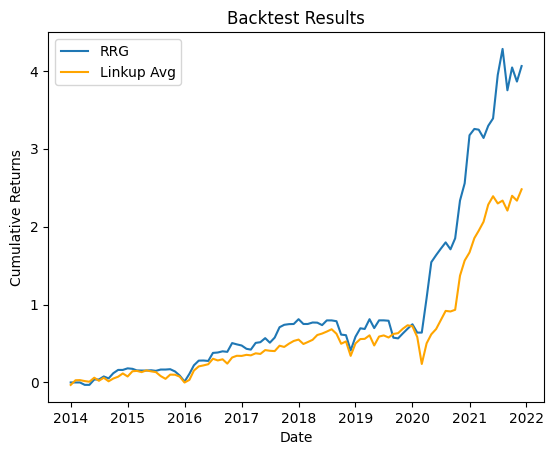

In [46]:
# Ensure dates are sorted
dates = sorted(joint['date'].unique())

long_sectors = []
short_sectors = []
returns = []
long_lag = 1   # months
short_lag = 1  # months

for i, date in enumerate(dates):
    if i >= long_lag:
        long_signal_date = dates[i - long_lag]
        long_signals = joint[joint['date'] == long_signal_date]
        long_sectors = long_signals[long_signals['rotation_direction'] == 'Lagging → Leading']['sector'].tolist()
    else:
        long_sectors = []

    if i >= short_lag:
        short_signal_date = dates[i - short_lag]
        short_signals = joint[joint['date'] == short_signal_date]
        short_sectors = short_signals[short_signals['quadrant'] == 'Improving']['sector'].tolist()
    else:
        short_sectors = []

    # Calculate returns for the current month
    current_month = joint[joint['date'] == date]
    long_return = current_month[current_month['sector'].isin(long_sectors)]['eq_weighted_return'].mean()
    short_return = current_month[current_month['sector'].isin(short_sectors)]['eq_weighted_return'].mean()

    # Momentum Strategy
    # net_return = long_return - short_return if not np.isnan(long_return) and not np.isnan(short_return) else 0
    # Long only strategy
    net_return = long_return if not np.isnan(long_return) else 0

    returns.append(net_return)
    
cumulative_returns = np.cumprod(1 + np.array(returns)) - 1
linkup_avg_returns = sector_return.groupby('month')['eq_weighted_return'].mean()

# --- Sharpe Ratio ---
rrg_sharpe = sharpe(returns)
linkup_sharpe = sharpe(linkup_avg_returns)
print(f"RRG Strategy Sharpe Ratio: {rrg_sharpe:.2f}")
print(f"Linkup Avg Sharpe Ratio: {linkup_sharpe:.2f}")

# --- Max Drawdown calculation ---
rrg_mdd = mdd(pd.Series(returns))
linkup_mdd = mdd(linkup_avg_returns)
print(f"RRG Strategy Max Drawdown: {rrg_mdd.min():.2%}")
print(f"Linkup Avg Max Drawdown: {linkup_mdd.min():.2%}")

plt.plot(joint['date'].unique(), cumulative_returns, label='RRG')
plt.plot(sector_return['month'].unique(), (1 + linkup_avg_returns).cumprod() - 1, label='Linkup Avg', color='orange')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.title('Backtest Results')
plt.legend()
plt.show()

# Alpha Analysis

In [47]:
factor_df = pd.read_excel('Carhart_4_Factors.xlsx', sheet_name='Monthly_Carhart', header=0)
mom_df = pd.read_excel('Carhart_4_Factors.xlsx', sheet_name='Monthly_MOM', header=0)

# parse Date (files use YYYYMMDD) and coerce invalid/footer rows
factor_df['Date'] = pd.to_datetime(factor_df['Date'], format='%Y%m', errors='coerce').dt.strftime('%Y-%m')
mom_df['Date'] = pd.to_datetime(mom_df['Date'], format='%Y%m', errors='coerce').dt.strftime('%Y-%m')

# merge, set Date as index and align to price_data index
carhart_df = pd.merge(factor_df, mom_df, on='Date', how='inner')
carhart_df = carhart_df.set_index('Date').sort_index()
joint_months = pd.to_datetime(joint['date'], errors='coerce').dt.strftime('%Y-%m')
carhart_df = carhart_df.loc[carhart_df.index.isin(joint_months.dropna())]

# ensure numeric and convert from percent to decimal
carhart_df = carhart_df.apply(pd.to_numeric, errors='coerce') / 100
carhart_df

,Mkt-RF,SMB,HML,RF,Mom
Date,,,,,
2014-01,-0.0332,0.0093,-0.0199,0.0000,0.0161
2014-02,0.0466,0.0036,-0.0035,0.0000,0.0213
2014-03,0.0043,-0.0186,0.0490,0.0000,-0.0327
2014-04,-0.0018,-0.0418,0.0122,0.0000,-0.0382
2014-05,0.0205,-0.0185,-0.0010,0.0000,0.0089
...,...,...,...,...,...
2021-08,0.0294,-0.0032,-0.0023,0.0000,0.0263
2021-09,-0.0440,0.0066,0.0512,0.0000,0.0139
2021-10,0.0663,-0.0226,-0.0053,0.0000,0.0332


In [48]:
# convert returns (list) to a pandas Series with proper month index, then align with Carhart factors
monthly_returns = pd.Series(returns, index=joint_months.unique(), name='strategy_return')

# align indices
common_idx = monthly_returns.index.intersection(carhart_df.index)

# y must be 1D for OLS
y = monthly_returns.loc[common_idx] - carhart_df.loc[common_idx, 'RF']
X = sm.add_constant(carhart_df.loc[common_idx, ['Mkt-RF', 'SMB', 'HML', 'Mom']])

# combine and drop any NaNs before regression
reg_df = pd.concat([y.rename('excess_return'), X], axis=1).dropna()
y_clean = reg_df['excess_return']
X_clean = reg_df.drop(columns='excess_return')

reg = sm.OLS(y_clean, X_clean).fit()
print(reg.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.488
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     21.66
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           1.40e-12
Time:                        02:47:36   Log-Likelihood:                 164.20
No. Observations:                  96   AIC:                            -318.4
Df Residuals:                      91   BIC:                            -305.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0085      0.005      1.752      0.0